# Intro

Name:  

    ARCSIX_KT19_june7

Purpose:  

    Look at the KT19 data in the ARCSIX, in the june 7 case where there was ice in cloud 

Input:

    none at command line

Output:

    plots

Keywords:

    none

Dependencies:

    - numpy
    - pandas

Needed Files:

  - kt19 ict files

Modification History:

    Written: Samuel LeBlanc, Santa Cruz, 2026-04-28
    Modified: 

# Load the required modules

In [1]:
%matplotlib widget

In [3]:
import matplotlib 
import matplotlib.pyplot as plt
import numpy as np
import os
import netCDF4 as nc
from datetime import datetime
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import json
import pandas as pd
import cartopy.crs as ccrs
from path_utils import getpath

In [4]:
import path_utils as pu
import load_utils as lu

In [5]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"

In [6]:
fp = getpath('ARCSIX')#,path=r"/data2/ARCSIX/data",make_path=True)
fp

Return path named:  ARCSIX /data2/ARCSIX/data/


'/data2/ARCSIX/data/'

# Load the files

In [11]:
fo = fp+'ARCSIX-MetNav-KT19-10Hz_P3B_20240607_R0.ict'
kt19 = lu.load_ict(fo)

('Time_Start', 'Latitude', 'Longitude', 'GPS_Altitude', 'IR_Surf_Temp')


# Plot some of the data

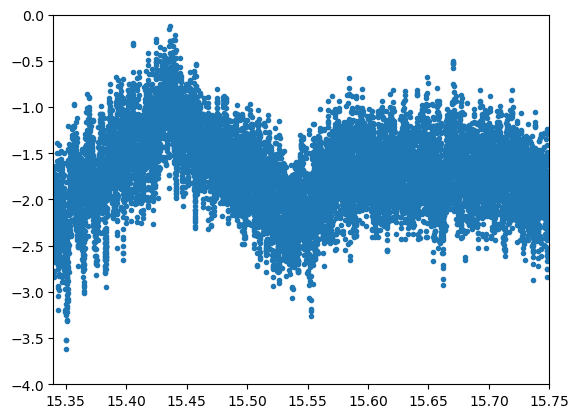

In [12]:
fig = plt.figure()
plt.plot(kt19['Time_Start']/3600.0,kt19['IR_Surf_Temp'],'.')
plt.xlim(15.34,15.75)
plt.ylim(-4,0)
plt.show()

In [13]:
import time

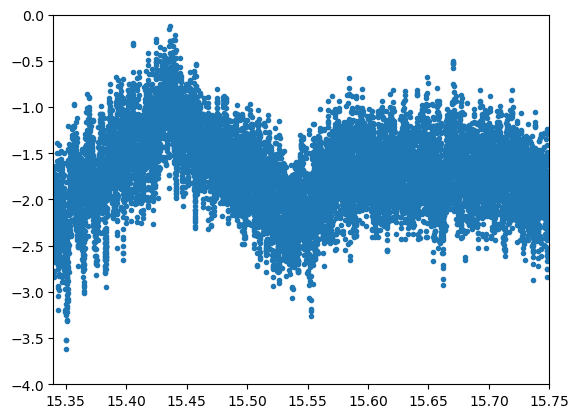

In [14]:
plt.close('all')
fig,ax = plt.subplots()
plt.plot(kt19['Time_Start']/3600.0,kt19['IR_Surf_Temp'],'.')
plt.xlim(15.34,15.75)
plt.ylim(-4,0)
fig.canvas.draw()
time.sleep(0.5)
display(fig.canvas)


In [10]:

fig = px.line(x=kt19['Time_Start']/3600.0,y=kt19['IR_Surf_Temp'])
fig.show()

# Load from earthdata

In [1]:
import earthaccess

/home/sam/mambaforge/envs/py314/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
earthaccess.login()

Enter your Earthdata Login username:  samuelleblanc
Enter your Earthdata password:  ········


In [4]:
results = earthaccess.search_datasets(
    keyword="MERRA-2"
    )

In [5]:
len(results)

224

In [19]:
results[0]['umm']['CollectionCitations'][0]['Title']

'MERRA-2 tavg1_2d_aer_Nx: 2d,1-Hourly,Time-averaged,Single-Level,Assimilation,Aerosol Diagnostics V5.12.4'

In [25]:
results[0]['meta']['native-id']

'M2T1NXAER_5.12.4'

In [27]:
results[0]['umm'].keys()

dict_keys(['DataLanguage', 'AncillaryKeywords', 'CollectionCitations', 'SpatialExtent', 'CollectionProgress', 'StandardProduct', 'ScienceKeywords', 'TemporalExtents', 'ProcessingLevel', 'DOI', 'ShortName', 'EntryTitle', 'PublicationReferences', 'ISOTopicCategories', 'DirectDistributionInformation', 'RelatedUrls', 'ContactGroups', 'DataDates', 'Abstract', 'LocationKeywords', 'MetadataDates', 'VersionDescription', 'Version', 'Projects', 'UseConstraints', 'ContactPersons', 'CollectionDataType', 'DataCenters', 'Platforms', 'MetadataSpecification', 'ArchiveAndDistributionInformation'])

In [37]:
results[4]['umm']['ShortName']

'M2I3NPASM'

In [38]:
results[4]['meta']['concept-id']

'C1276812879-GES_DISC'

In [28]:
results[0]['meta'].keys()

dict_keys(['revision-id', 'deleted', 'format', 'provider-id', 'has-combine', 'user-id', 'has-formats', 'associations', 's3-links', 'has-spatial-subsetting', 'native-id', 'has-transforms', 'association-details', 'has-variables', 'concept-id', 'revision-date', 'has-temporal-subsetting', 'concept-type'])

In [58]:
[(r['meta']['concept-id'],r['umm']['CollectionCitations'][0].get('Title','NA')) for r in results if 'CollectionCitations' in r['umm']]

[('C1276812830-GES_DISC',
  'MERRA-2 tavg1_2d_aer_Nx: 2d,1-Hourly,Time-averaged,Single-Level,Assimilation,Aerosol Diagnostics V5.12.4'),
 ('C1276812863-GES_DISC',
  'MERRA-2 tavg1_2d_slv_Nx: 2d,1-Hourly,Time-Averaged,Single-Level,Assimilation,Single-Level Diagnostics V5.12.4'),
 ('C1276812838-GES_DISC',
  'MERRA-2 tavg1_2d_flx_Nx: 2d,1-Hourly,Time-Averaged,Single-Level,Assimilation,Surface Flux Diagnostics V5.12.4'),
 ('C1276812851-GES_DISC',
  'MERRA-2 tavg1_2d_rad_Nx: 2d,1-Hourly,Time-Averaged,Single-Level,Assimilation,Radiation Diagnostics V5.12.4'),
 ('C1276812879-GES_DISC',
  'MERRA-2 inst3_3d_asm_Np: 3d,3-Hourly,Instantaneous,Pressure-Level,Assimilation,Assimilated Meteorological Fields V5.12.4'),
 ('C1276812820-GES_DISC',
  'MERRA-2 inst1_2d_asm_Nx: 2d,1-Hourly,Instantaneous,Single-Level,Assimilation,Single-Level Diagnostics V5.12.4'),
 ('C1276812882-GES_DISC',
  'MERRA-2 inst3_3d_aer_Nv: 3d,3-Hourly,Instantaneous,Model-Level,Assimilation,Aerosol Mixing Ratio V5.12.4'),
 ('C1276

In [41]:
res = earthaccess.search_data(concept_id='C1276812879-GES_DISC',temporal=("2024-05-17","2024-06-17"))

/home/sam/mambaforge/envs/py314/lib/python3.14/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [46]:
res = earthaccess.search_data(concept_id='C1276812879-GES_DISC',temporal=("2024-06-07","2024-06-08")) # 3d

In [47]:
res

[Collection: {'ShortName': 'M2I3NPASM', 'Version': '5.12.4'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-06-07T00:00:00.000Z', 'EndingDateTime': '2024-06-07T21:00:00.000Z'}}
 Size(MB): 1140.6122817993164
 Data: ['https://data.gesdisc.earthdata.nasa.gov/data/MERRA2/M2I3NPASM.5.12.4/2024/06/MERRA2_400.inst3_3d_asm_Np.20240607.nc4'],
 Collection: {'ShortName': 'M2I3NPASM', 'Version': '5.12.4'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-06-08T00:00:00.000Z', 'EndingDateTime': '2024-06-08T21:00:00.000Z'}}
 Si

In [52]:
fileobjects = earthaccess.download([res[0]],local_path='/data2/ARCSIX/data/')

QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 587.93it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:32<00:00, 32.59s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 8756.38it/s]


In [53]:
fileobjects

[PosixPath('/data2/ARCSIX/data/MERRA2_400.inst3_3d_asm_Np.20240607.nc4')]

In [59]:
res2d = earthaccess.search_data(concept_id='C1276812863-GES_DISC',temporal=("2024-06-07","2024-06-08"))

/home/sam/mambaforge/envs/py314/lib/python3.14/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [60]:
res2d

/home/sam/mambaforge/envs/py314/lib/python3.14/site-packages/earthaccess/results.py:364: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  Size(MB): {self.size()}


[Collection: {'ShortName': 'M2T1NXSLV', 'Version': '5.12.4'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-06-07T00:00:00.000Z', 'EndingDateTime': '2024-06-07T23:59:59.000Z'}}
 Size(MB): 394.8500509262085
 Data: ['https://data.gesdisc.earthdata.nasa.gov/data/MERRA2/M2T1NXSLV.5.12.4/2024/06/MERRA2_400.tavg1_2d_slv_Nx.20240607.nc4'],
 Collection: {'ShortName': 'M2T1NXSLV', 'Version': '5.12.4'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-06-08T00:00:00.000Z', 'EndingDateTime': '2024-06-08T23:59:59.000Z'}}
 Siz

In [61]:
fileobjects2d = earthaccess.download([res2d[0]],local_path='/data2/ARCSIX/data/')

/home/sam/mambaforge/envs/py314/lib/python3.14/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 1194.62it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:13<00:00, 13.21s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 7244.05it/s]


## load the MERRA-2 file

In [55]:
import xarray

In [56]:
ds = xarray.open_dataset(fileobjects[0])

In [62]:
ds2d = xarray.open_dataset(fileobjects2d[0])

In [65]:
ds2d['TROPQ']

<xarray.DataArray 'TROPQ' (time: 24, lat: 361, lon: 576)> Size: 20MB
[4990464 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 192B 2024-06-07T00:30:00 ... 2024-06-07T23...
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
Attributes:
    long_name:       tropopause_specific_humidity_using_blended_TROPP_estimate
    units:           kg kg-1
    fmissing_value:  1e+15
    standard_name:   tropopause_specific_humidity_using_blended_TROPP_estimate
    vmax:            1e+15
    vmin:            -1e+15
    valid_range:     [-1.e+15  1.e+15]